In [1]:
!pip install -q transformers accelerate bitsandbytes datasets scikit-learn torch huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import torch
from transformers import pipeline
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, BertForMaskedLM
from sklearn.metrics import f1_score, classification_report
from tqdm import tqdm
from huggingface_hub import login
from google.colab import userdata


hf_token = userdata.get('hf_token')
login(token=hf_token)

In [3]:
data = pd.read_csv('FinTextSen_clean.csv')

# Limpieza minima para evitar prompts vacios o etiquetas no numericas
data = data.dropna(subset=['sentences', 'labels']).copy()
data['sentences'] = data['sentences'].astype(str).str.strip()
data = data[data['sentences'] != ''].copy()
data['labels'] = data['labels'].astype(int)
print(f"Filas validas para inferencia: {len(data)}")
data.head()

Filas validas para inferencia: 1680


,sentences,labels
0,watching for bounce tomorrow,2
1,record number of passengers served in 2015,2
2,out $NFLX -.35,0
3,"Looking for a strong bounce, Lunchtime rally c...",2
4,Very intrigued with the technology and growth ...,2


In [4]:
model_id = "meta-llama/Llama-3.2-1B-Instruct"
pipe = pipeline(
    "text-generation",
    model=model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

In [5]:
def clean_pipeline_prediction(output_list):
    """Extracts and cleans the sentiment from the pipeline output."""
    if output_list and len(output_list) > 0 and 'generated_text' in output_list[0]:
        assistant_response = output_list[0]['generated_text'][-1]
        if 'content' in assistant_response:
            response_text = assistant_response['content'].lower().strip()
            if 'positive' in response_text:
                return 'positive'
            elif 'negative' in response_text:
                return 'negative'
            elif 'neutral' in response_text:
                return 'neutral'
    return 'unknown'

In [6]:
predicted_sentiments = []

for index, row in data.iterrows():
    sentence = row['sentences']
    messages = [
        {"role": "system", "content": "You're an expert financial sentiment analyst, and you make no mistakes on your choices. Also you only answer with positive, negative or neutral"},
        {"role": "user", "content": f"Sentence: {sentence} Clasiffy the sentiment of this sentence as Positive, Negative or Neutral, CHOOSE just one"},
    ]
    outputs = pipe(
        messages,
        max_new_tokens=5,
    )
    predicted_sentiment = clean_pipeline_prediction(outputs)
    predicted_sentiments.append(predicted_sentiment)

print(f"Total predictions: {len(predicted_sentiments)}")
print("First 5 predicted sentiments:", predicted_sentiments[:5])

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_outp

Total predictions: 1680
First 5 predicted sentiments: ['neutral', 'neutral', 'neutral', 'neutral', 'neutral']


In [7]:
predicted_sentiments_df = pd.DataFrame(predicted_sentiments, columns=['predicted_sentiment'])
display(predicted_sentiments_df.head())

sentiment_to_label = {'negative': 0, 'neutral': 1, 'positive': 2}
predicted_labels = [sentiment_to_label.get(sentiment, -1) for sentiment in predicted_sentiments]
valid_prediction_mask = np.array(predicted_labels) != -1

print("\nResultados Llama 3.2 1B Instruct (zero-shot):")
print("Predicciones validas:", int(valid_prediction_mask.sum()), "de", len(predicted_labels))
print("Micro F1:", f1_score(data['labels'].to_numpy()[valid_prediction_mask], np.array(predicted_labels)[valid_prediction_mask], average='micro'))
print("Macro F1:", f1_score(data['labels'].to_numpy()[valid_prediction_mask], np.array(predicted_labels)[valid_prediction_mask], average='macro'))
print(classification_report(data['labels'].to_numpy()[valid_prediction_mask], np.array(predicted_labels)[valid_prediction_mask], target_names=['negative', 'neutral', 'positive']))

,predicted_sentiment
0,neutral
1,neutral
2,neutral
3,neutral
4,neutral



Resultados Llama 3.2 1B Instruct (zero-shot):
Predicciones validas: 1659 de 1680
Micro F1: 0.32248342374924654
Macro F1: 0.28552111743624375
              precision    recall  f1-score   support

    negative       0.54      0.27      0.36       573
     neutral       0.01      0.69      0.02        16
    positive       0.76      0.35      0.48      1070

    accuracy                           0.32      1659
   macro avg       0.44      0.43      0.29      1659
weighted avg       0.67      0.32      0.43      1659



In [8]:
# predicted_sentiments_df.to_csv('predicted_sentiments_FinTextSen.csv', index=False)
# print("Predicted sentiments saved to 'predicted_sentiments_FinTextSen.csv'")

# Usando técnica de Few Shot

In [9]:
# Find an example for each sentiment (assuming labels are 0:negative, 1:neutral, 2:positive)
positive_example = data[data['labels'] == 2].iloc[0]
neutral_example = data[data['labels'] == 1].iloc[0]
negative_example = data[data['labels'] == 0].iloc[0]

few_shot_examples = [
    {
        "role": "user",
        "content": f"Sentence: {positive_example['sentences']} Clasiffy the sentiment of this sentence as Positive, Negative or Neutral, CHOOSE just one"
    },
    {"role": "assistant", "content": "positive"},
    {
        "role": "user",
        "content": f"Sentence: {neutral_example['sentences']} Clasiffy the sentiment of this sentence as Positive, Negative or Neutral, CHOOSE just one"
    },
    {"role": "assistant", "content": "neutral"},
    {
        "role": "user",
        "content": f"Sentence: {negative_example['sentences']} Clasiffy the sentiment of this sentence as Positive, Negative or Neutral, CHOOSE just one"
    },
    {"role": "assistant", "content": "negative"}
]

In [10]:
fewshot_predicted_sentiments = []

for index, row in data.iterrows():
    sentence = row['sentences']

    # Combine system message, few-shot examples, and the current sentence for prediction
    messages_with_few_shot = [
        {"role": "system", "content": "You're an expert financial sentiment analyst, and you make no mistakes on your choices. Also you only answer with positive, negative or neutral"}
    ] + few_shot_examples + [
        {"role": "user", "content": f"Sentence: {sentence} Clasiffy the sentiment of this sentence as Positive, Negative or Neutral, CHOOSE just one"}
    ]

    outputs = pipe(
        messages_with_few_shot,
        max_new_tokens=5,
    )
    fewshot_predicted_sentiment = clean_pipeline_prediction(outputs)
    fewshot_predicted_sentiments.append(fewshot_predicted_sentiment)

print(f"Total Few-Shot predictions: {len(fewshot_predicted_sentiments)}")
print("First 5 Few-Shot predicted sentiments:", fewshot_predicted_sentiments[:5])


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/t

Total Few-Shot predictions: 1680
First 5 Few-Shot predicted sentiments: ['positive', 'positive', 'neutral', 'positive', 'positive']


In [11]:
fewshot_predicted_sentiments_df = pd.DataFrame(fewshot_predicted_sentiments, columns=['fewshot_predicted_sentiment'])
display(fewshot_predicted_sentiments_df.head())

fewshot_predicted_labels = [sentiment_to_label.get(sentiment, -1) for sentiment in fewshot_predicted_sentiments]
fewshot_valid_prediction_mask = np.array(fewshot_predicted_labels) != -1

print("\nResultados Llama 3.2 1B Instruct (few-shot):")
print("Predicciones validas:", int(fewshot_valid_prediction_mask.sum()), "de", len(fewshot_predicted_labels))
print("Micro F1:", f1_score(data['labels'].to_numpy()[fewshot_valid_prediction_mask], np.array(fewshot_predicted_labels)[fewshot_valid_prediction_mask], average='micro'))
print("Macro F1:", f1_score(data['labels'].to_numpy()[fewshot_valid_prediction_mask], np.array(fewshot_predicted_labels)[fewshot_valid_prediction_mask], average='macro'))
print(classification_report(data['labels'].to_numpy()[fewshot_valid_prediction_mask], np.array(fewshot_predicted_labels)[fewshot_valid_prediction_mask], target_names=['negative', 'neutral', 'positive']))

,fewshot_predicted_sentiment
0,positive
1,positive
2,neutral
3,positive
4,positive



Resultados Llama 3.2 1B Instruct (few-shot):
Predicciones validas: 1680 de 1680
Micro F1: 0.6773809523809524
Macro F1: 0.3527666206253528
              precision    recall  f1-score   support

    negative       0.94      0.14      0.25       578
     neutral       0.00      0.00      0.00        16
    positive       0.70      0.97      0.81      1086

    accuracy                           0.68      1680
   macro avg       0.55      0.37      0.35      1680
weighted avg       0.77      0.68      0.61      1680



In [12]:
fewshot_predicted_sentiments_df.to_csv('fewshot_predicted_sentiments_FinTextSen.csv', index=False)
print("Few-shot predicted sentiments saved to 'fewshot_predicted_sentiments_FinTextSen.csv'")

Few-shot predicted sentiments saved to 'fewshot_predicted_sentiments_FinTextSen.csv'


## Matrices de confusión - Llama 3.2 1B Instruct

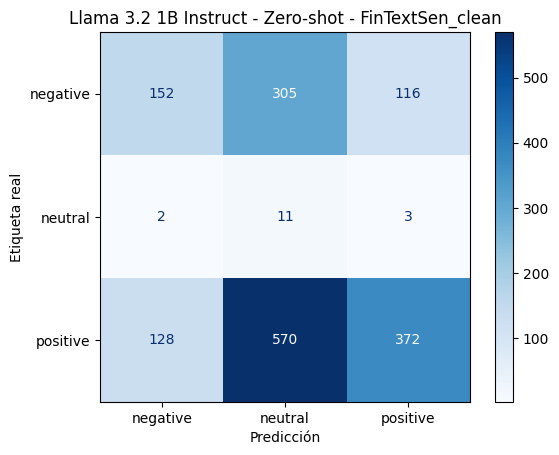

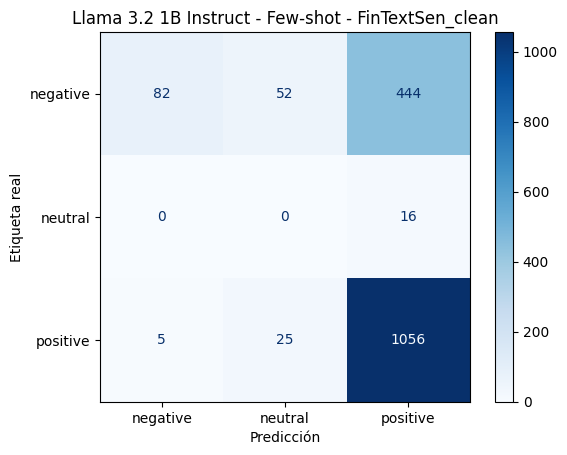

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = [0, 1, 2]
display_labels = ['negative', 'neutral', 'positive']

# Zero-shot: se excluyen predicciones unknown para mantener consistencia con el cálculo de F1.
y_true_zero = data['labels'].to_numpy()[valid_prediction_mask]
y_pred_zero = np.array(predicted_labels)[valid_prediction_mask]

cm_zero = confusion_matrix(y_true_zero, y_pred_zero, labels=labels)
disp_zero = ConfusionMatrixDisplay(confusion_matrix=cm_zero, display_labels=display_labels)
disp_zero.plot(cmap='Blues', values_format='d')
plt.title('Llama 3.2 1B Instruct - Zero-shot - FinTextSen_clean')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.savefig('llama32_1b_zero_shot_confusion_matrix.png')
plt.show()

# Few-shot: se excluyen predicciones unknown si existieran.
y_true_few = data['labels'].to_numpy()[fewshot_valid_prediction_mask]
y_pred_few = np.array(fewshot_predicted_labels)[fewshot_valid_prediction_mask]

cm_few = confusion_matrix(y_true_few, y_pred_few, labels=labels)
disp_few = ConfusionMatrixDisplay(confusion_matrix=cm_few, display_labels=display_labels)
disp_few.plot(cmap='Blues', values_format='d')
plt.title('Llama 3.2 1B Instruct - Few-shot - FinTextSen_clean')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.savefig('llama32_1b_few_shot_confusion_matrix.png')
plt.show()
